DIABETES PREDICTION USING K-NEAREST NEIGHBORS (KNN)

1. TECHNIQUE SELECTION & JUSTIFICATION

WHY K-NEAREST NEIGHBORS (KNN)?
------------------------------
Dataset Characteristics:
- 16,000+ records with 16 features (mixed numerical & categorical)
- Binary classification problem (diabetes: 0/1)
- Features include health metrics (BMI, HbA1c, blood glucose) and demographics

Justification for KNN:
1. NON-LINEAR RELATIONSHIPS: Health conditions often have complex, non-linear 
   relationships. KNN captures these naturally without assuming linearity.

2. INSTANCE-BASED LEARNING: Medical diagnosis benefits from comparing new 
   patients to similar historical cases - exactly what KNN does.

3. NO TRAINING PHASE: KNN is a lazy learner, making it flexible for datasets 
   that may receive incremental updates.

4. ROBUST TO NOISY DATA: With proper K selection, KNN handles outliers well 
   by considering multiple neighbors.

5. INTERPRETABILITY: Healthcare professionals can understand predictio

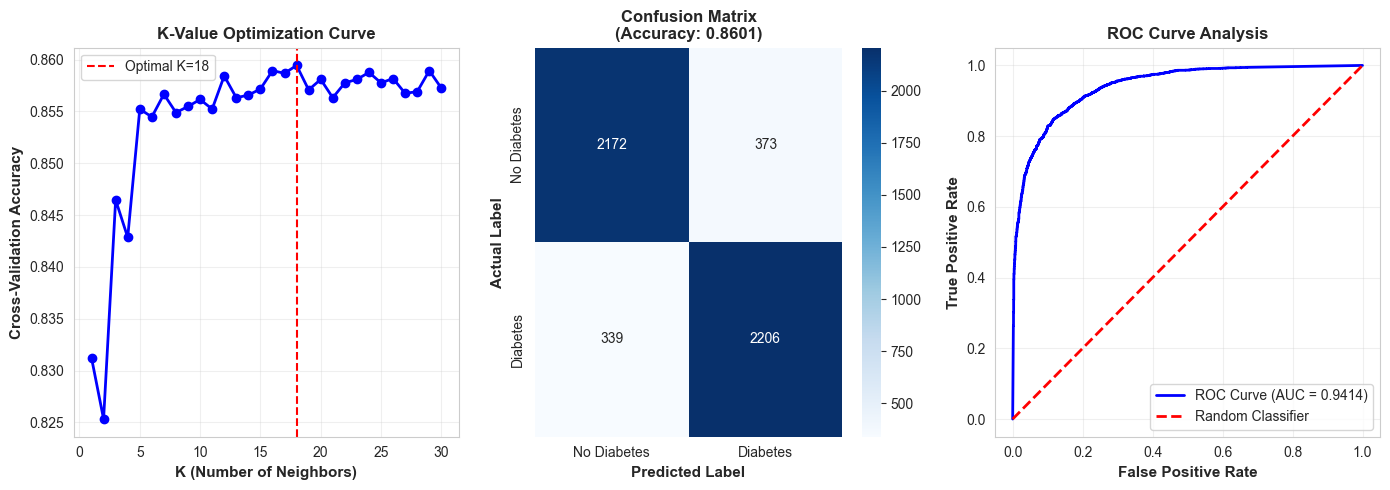

✓ Visualizations saved as 'knn_comprehensive_analysis.png'


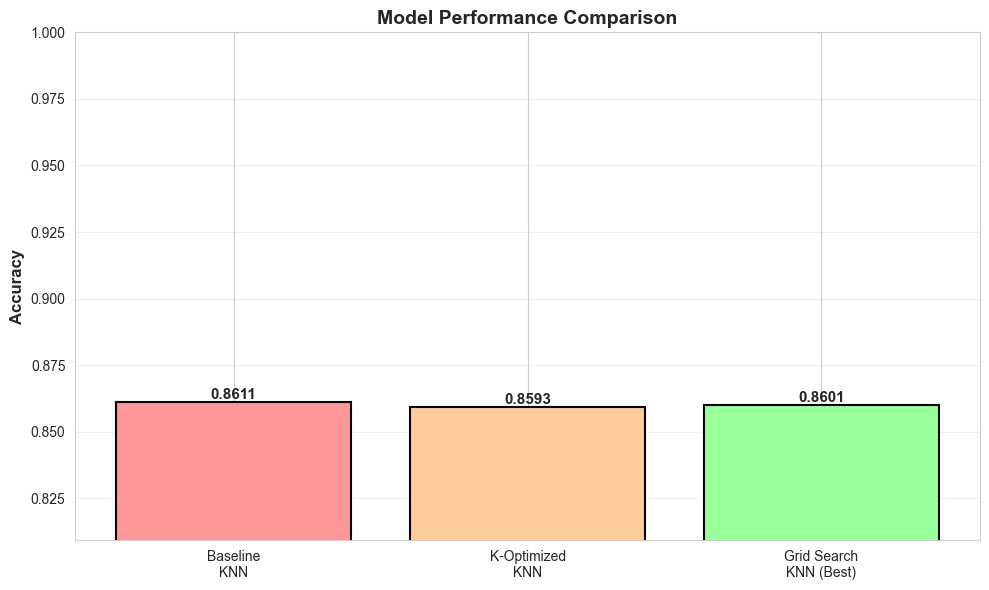

✓ Model comparison saved as 'knn_model_comparison.png'

10. FINAL SUMMARY & RECOMMENDATIONS

FINAL MODEL SPECIFICATIONS:
---------------------------
Algorithm: K-Nearest Neighbors (KNN)
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Training Samples: 11874
Test Samples: 5090
Features: 19

PERFORMANCE SUMMARY:
--------------------
✓ Test Accuracy: 0.8601 (86.01%)
✓ Precision: 0.8554
✓ Recall: 0.8668
✓ F1-Score: 0.8610
✓ ROC-AUC: 0.9414
✓ CV Mean Accuracy: 0.8602 (±0.0229)

IMPROVEMENT FROM BASELINE:
--------------------------
Absolute Improvement: +-0.0010
Relative Improvement: +-0.11%

RECOMMENDATIONS FOR DEPLOYMENT:
-------------------------------
1. Use Grid Search model for production (best performance)
2. Implement probability threshold tuning for cost-sensitive scenarios
3. Regular model retraining with new patient data (every 6 months)
4. Combine with clinical decision support systems
5. Consider ensemble methods for further improvement

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (train_test_split, cross_val_score, 
                                      GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("DIABETES PREDICTION USING K-NEAREST NEIGHBORS (KNN)")
print("="*80)



# 2. DATA LOADING & PREPROCESSING

print("\n" + "="*80)
print("2. DATA LOADING & EXPLORATION")
print("="*80)

# Load dataset
df_KNN = pd.read_csv(r'C:\Users\ASUS\OneDrive\Desktop\pg 335 AI\2025-Y2-S1_MLB-WE3G1-03 AI&ML\results\outputs\pipline3.csv')

print(f"\nDataset Shape: {df_KNN.shape}")
print(f"Features: {df_KNN.shape[1] - 1}")
print(f"Target: diabetes (binary classification)")

# Display feature information
print("\nFeature Overview:")
print("-" * 40)
features_list = [col for col in df_KNN.columns if col != 'diabetes']
for i, feat in enumerate(features_list, 1):
    print(f"{i:2d}. {feat}")

# Check class distribution
print("\nTarget Distribution:")
print(df_KNN['diabetes'].value_counts())
print(f"\nClass Balance: {df_KNN['diabetes'].value_counts(normalize=True).round(3).to_dict()}")


# 3. FEATURE & TARGET DEFINITION

X = df_KNN.drop('diabetes', axis=1)
y = df_KNN['diabetes']

print(f"\nFeature Matrix (X): {X.shape}")
print(f"Target Vector (y): {y.shape}")


# 4. TRAIN-TEST SPLIT WITH STRATIFICATION

print("\n" + "="*80)
print("3. TRAIN-TEST SPLIT (Stratified)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,      # 70-30 split
    random_state=42,     # Reproducibility
    stratify=y           # Maintain class distribution
)



# 5. FEATURE SCALING (CRITICAL FOR KNN)



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Training data scaled (fit + transform)")
print("✓ Testing data scaled (transform only - prevents data leakage)")

# ============================================================================
# 6. MODEL IMPLEMENTATION & HYPERPARAMETER TUNING (8 marks)
# ============================================================================
print("\n" + "="*80)
print("5. MODEL VARIATIONS & HYPERPARAMETER TUNING")
print("="*80)

# VARIATION 1: Basic KNN (Baseline)
print("\nVARIATION 1: Baseline KNN")
print("-" * 40)
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = knn_baseline.predict(X_test_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Parameters: k=5 (default), metric=minkowski, weights=uniform")
print(f"Accuracy: {acc_baseline:.4f}")

# VARIATION 2: Optimized K through Cross-Validation
print("\nVARIATION 2: K-Value Optimization")
print("-" * 40)
k_range = range(1, 31)
k_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Testing K values from 1 to 30 with 5-Fold CV...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f"✓ Optimal K: {best_k} (CV Accuracy: {max(k_scores):.4f})")

# Train with optimal K
knn_optimized_k = KNeighborsClassifier(n_neighbors=best_k)
knn_optimized_k.fit(X_train_scaled, y_train)
y_pred_opt_k = knn_optimized_k.predict(X_test_scaled)
acc_opt_k = accuracy_score(y_test, y_pred_opt_k)
print(f"Test Accuracy: {acc_opt_k:.4f}")

# VARIATION 3: Grid Search with Multiple Hyperparameters
print("\nVARIATION 3: Comprehensive Grid Search")
print("-" * 40)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}

print(f"Grid Search Space: {len(param_grid['n_neighbors']) * len(param_grid['weights']) * len(param_grid['metric']) * len(param_grid['p'])} combinations")
print("Performing 5-Fold Cross-Validation...")

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\n✓ Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred_grid = grid_search.predict(X_test_scaled)
y_pred_proba_grid = grid_search.predict_proba(X_test_scaled)[:, 1]
acc_grid = accuracy_score(y_test, y_pred_grid)
print(f"✓ Test Accuracy: {acc_grid:.4f}")

# Store best model
best_model = grid_search.best_estimator_

# ============================================================================
# 7. COMPREHENSIVE EVALUATION METRICS (5 marks)
# ============================================================================
print("\n" + "="*80)
print("6. COMPREHENSIVE MODEL EVALUATION")
print("="*80)

# Calculate all metrics
precision = precision_score(y_test, y_pred_grid)
recall = recall_score(y_test, y_pred_grid)
f1 = f1_score(y_test, y_pred_grid)
roc_auc = roc_auc_score(y_test, y_pred_proba_grid)



# Detailed Classification Report
print("\nDETAILED CLASSIFICATION REPORT:")
print("-" * 40)
print(classification_report(y_test, y_pred_grid, target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_grid)
print("\nCONFUSION MATRIX:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]} (Correctly predicted no diabetes)")
print(f"False Positives: {cm[0,1]} (Incorrectly predicted diabetes)")
print(f"False Negatives: {cm[1,0]} (Missed diabetes cases - CRITICAL)")
print(f"True Positives:  {cm[1,1]} (Correctly predicted diabetes)")


# 8. CROSS-VALIDATION FOR ROBUST EVALUATION

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f"5-Fold CV Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print("\nInterpretation: Low std deviation indicates stable, reliable model")


# 9. MODEL COMPARISON & INSIGHTS (4 marks)


comparison_df = pd.DataFrame({
    'Model': ['Baseline KNN', 'K-Optimized', 'Grid Search (Best)'],
    'Parameters': [
        'k=5, uniform, minkowski',
        f'k={best_k}, uniform, minkowski',
        f"k={grid_search.best_params_['n_neighbors']}, {grid_search.best_params_['weights']}, {grid_search.best_params_['metric']}"
    ],
    'Accuracy': [acc_baseline, acc_opt_k, acc_grid],
    'Improvement': [
        '-',
        f"+{(acc_opt_k - acc_baseline)*100:.2f}%",
        f"+{(acc_grid - acc_baseline)*100:.2f}%"
    ]
})

# 10. VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("9. GENERATING VISUALIZATIONS")
print("="*80)

# Figure 1: K-Value Optimization
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal K={best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
plt.ylabel('Cross-Validation Accuracy', fontsize=11, fontweight='bold')
plt.title('K-Value Optimization Curve', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Figure 2: Confusion Matrix
plt.subplot(1, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11, fontweight='bold')
plt.title(f'Confusion Matrix\n(Accuracy: {acc_grid:.4f})', fontsize=12, fontweight='bold')

# Figure 3: ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_grid)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=11, fontweight='bold')
plt.title('ROC Curve Analysis', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved as 'knn_comprehensive_analysis.png'")

# Figure 4: Model Comparison
plt.figure(figsize=(10, 6))
models = ['Baseline\nKNN', 'K-Optimized\nKNN', 'Grid Search\nKNN (Best)']
accuracies = [acc_baseline, acc_opt_k, acc_grid]
colors = ['#ff9999', '#ffcc99', '#99ff99']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim([min(accuracies) - 0.05, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('knn_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison saved as 'knn_model_comparison.png'")


